In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('age_children_income_1000.csv')
df.head()

,age,number_of_children,income
0,42.772420,0,34396.537188
1,29.561090,0,183350.052521
2,54.380735,0,53689.856555
3,42.551689,0,109080.913926
4,38.713080,0,153612.343419


In [5]:
pd.options.display.max_rows = 1000

In [7]:
df.number_of_children.value_counts()

number_of_children
0    658
1    226
2     94
3     20
5      1
4      1
Name: count, dtype: int64

In [9]:
df.number_of_children.value_counts(normalize = True)

number_of_children
0    0.658
1    0.226
2    0.094
3    0.020
5    0.001
4    0.001
Name: proportion, dtype: float64

<Axes: >

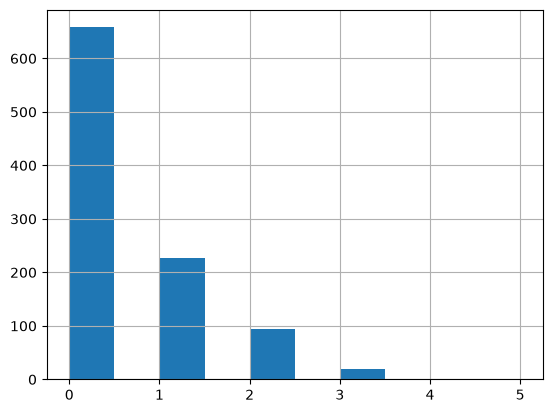

In [11]:
df.number_of_children.hist()

<Axes: xlabel='number_of_children', ylabel='Count'>

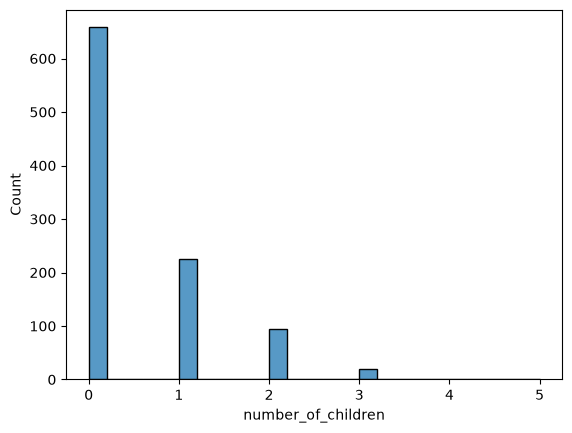

In [12]:
import seaborn as sns
sns.histplot(df.number_of_children)

<Axes: xlabel='number_of_children', ylabel='Probability'>

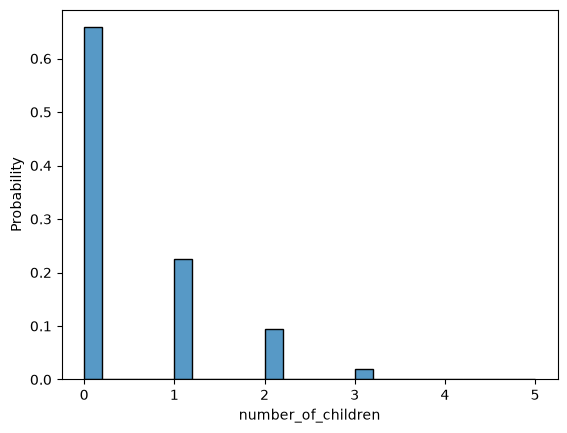

In [14]:
sns.histplot(df.number_of_children, stat = 'probability')

<Axes: >

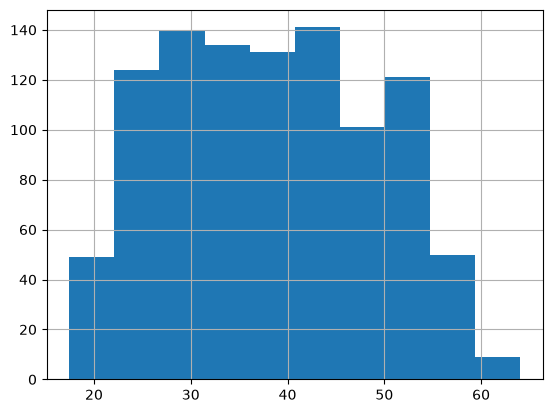

In [15]:
df.age.hist()

<Axes: xlabel='age', ylabel='Probability'>

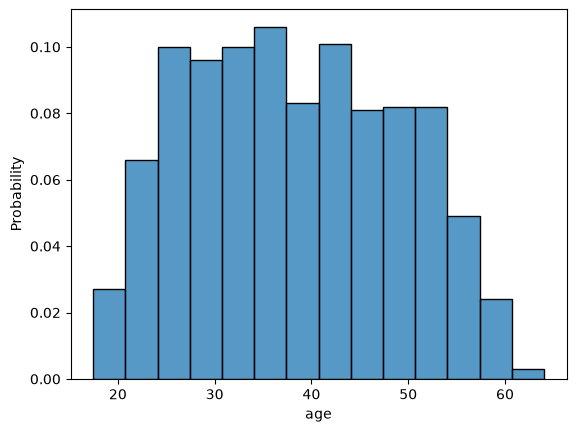

In [16]:
sns.histplot(df.age,stat ='probability')

In [57]:
df['age_bin'] = pd.cut(df.age,10)
df.groupby('age_bin')['age'].count()

age_bin
(17.402, 22.107]     49
(22.107, 26.766]    124
(26.766, 31.425]    140
(31.425, 36.084]    134
(36.084, 40.743]    131
(40.743, 45.401]    141
(45.401, 50.06]     101
(50.06, 54.719]     121
(54.719, 59.378]     50
(59.378, 64.037]      9
Name: age, dtype: int64

In [20]:
df.number_of_children.mean()

np.float64(0.483)

In [22]:
df.age.mean()

np.float64(38.31925590719966)

In [26]:
df.mean()

age                       38.319256
number_of_children         0.483000
income                129415.746378
dtype: float64

In [ ]:
#Проблема Билла Гейтса
salary = pd.Series([30,30,40,60,50,90000000])
salary.mean()# среднее всегда правильно, но оно не всегда отражает действительность

np.float64(15000035.0)

<Axes: >

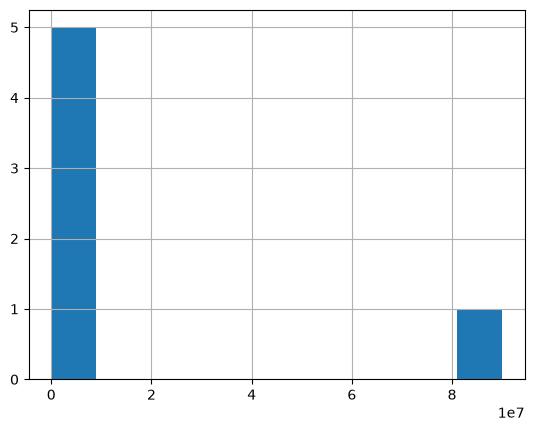

In [ ]:
salary.hist() #перекошенное распределение - жирный хвост

In [ ]:
salary.median()# число по середине

np.float64(45.0)

In [31]:
df.income.median()

np.float64(114586.57093898312)

In [32]:
(df.income < df.income.median()).mean()

np.float64(0.5)

In [34]:
df.income.agg(['mean','median'])

mean      129415.746378
median    114586.570939
Name: income, dtype: float64

<Axes: >

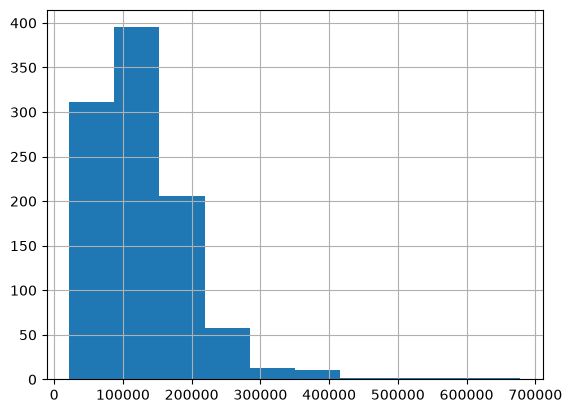

In [35]:
df['income'].hist()

In [37]:
(df['income'] < 100000).mean()

np.float64(0.397)

In [38]:
(df.income.quantile(0.4))

np.float64(100512.68685217279)

In [40]:
df['pct'] = df['age'].rank(pct=True)
(df.age < 42.772420).mean()

np.float64(0.638)

<Axes: >

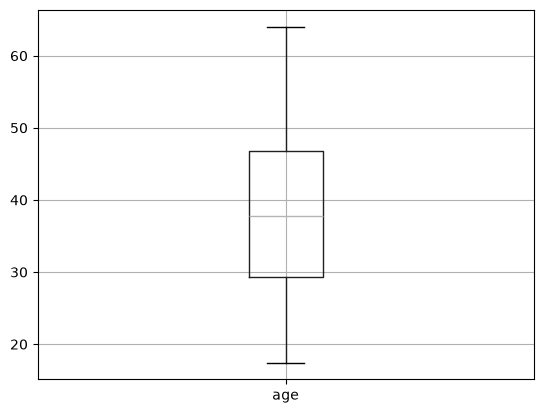

In [41]:
df.boxplot('age')

<Axes: >

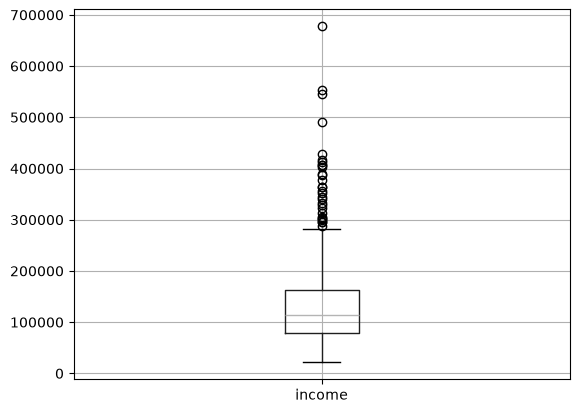

In [42]:
df.boxplot('income')

<Axes: ylabel='income'>

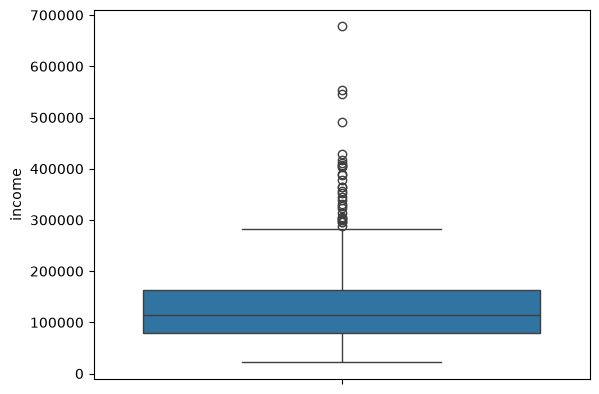

In [44]:
sns.boxplot(df['income'])

In [46]:
df.income.describe()

count      1000.000000
mean     129415.746378
std       71251.620971
min       21943.855414
25%       79594.040400
50%      114586.570939
75%      162888.891081
max      678006.351857
Name: income, dtype: float64

<Axes: >

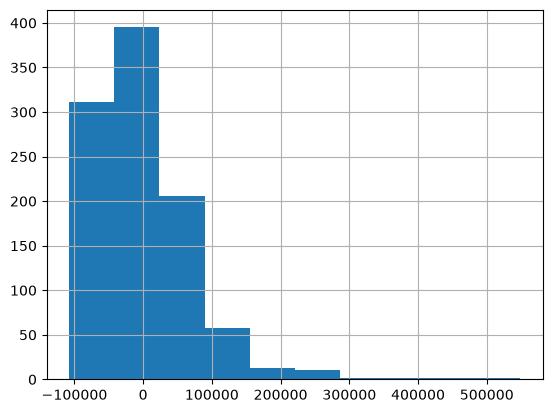

In [49]:
(df.income - df.income.mean()).hist()

In [50]:
(df.income - df.income.mean()).mean()

np.float64(5.1222741603851315e-12)

In [51]:
(df.income - df.income.mean()).abs().mean()

np.float64(51910.29730549474)

In [55]:
np.sqrt(((df.income - df.income.mean())**2).mean()) #std -дисперсия - стандартное отклонение

np.float64(71215.98624927517)

In [56]:
df[['age','income']].corr()

,age,income
age,1.000000,-0.048164
income,-0.048164,1.000000


In [58]:
df.groupby('age_bin')['income'].agg(['count','mean','median'])

,count,mean,median
age_bin,,,
"(17.402, 22.107]",49,104319.382165,88163.526875
"(22.107, 26.766]",124,133775.791324,125960.906191
"(26.766, 31.425]",140,130575.738767,114947.477353
"(31.425, 36.084]",134,135654.848704,118368.874351
"(36.084, 40.743]",131,134457.081592,128647.922872
"(40.743, 45.401]",141,139697.676942,123441.920529
"(45.401, 50.06]",101,142814.622910,122199.047306
"(50.06, 54.719]",121,112563.104588,95443.103632
"(54.719, 59.378]",50,104040.538214,91602.734609


<Axes: xlabel='age_bin'>

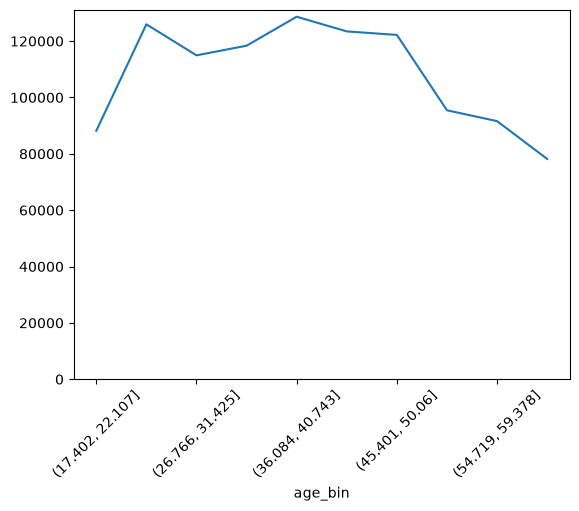

In [60]:
df.groupby('age_bin')['income'].median().plot(rot=45,ylim=0)